In [1]:
from src.incertidumbres import (
    graficar_imagen,
    crear_dataframe_incertidumbre,
    plot_incertidumbres,
    plot_combinado
)
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
import pickle
import pandas as pd
import tensorflow as tf

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"./models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
with open(f'./models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [4]:
preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("src/data/images_test/images_spectograms")
data.head()

,label,image_path
0,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [5]:
sp_metrics = pd.read_csv("models/metrics_resnet.csv")

In [6]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp.sample(6)

,label,image_path
14690,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_2.jpeg
14684,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_10.jpeg
14657,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/247442_4.jpeg
14686,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/738627_0.jpeg
14679,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/224883_1.jpeg
14694,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/586950_7.jpeg


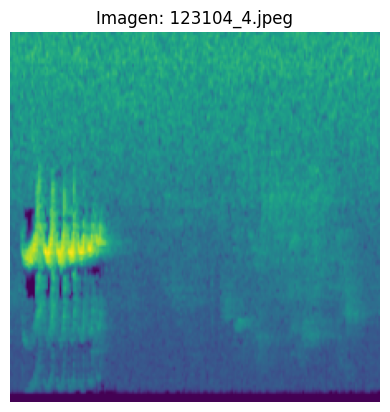

In [7]:
graficar_imagen(sp['image_path'].iloc[32])

# **Volatinia jacarina**

In [8]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [9]:
df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Volatinia jacarina)


2025-04-21 21:18:18.020386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [12:27<00:00, 747.61s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,651,0.01,1,1,6.44
1,Volatinia jacarina,651,651,651,0.01,1,1,6.44
2,Volatinia jacarina,651,651,651,0.01,1,1,6.44
3,Volatinia jacarina,651,651,651,0.01,1,1,6.44
4,Volatinia jacarina,651,651,651,0.01,1,1,6.44


In [10]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [11]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,0.91
1,114,0.05
2,205,0.01
3,298,0.01
4,464,0.01
5,547,0.00
6,17,0.00
8,650,0.00
9,554,0.00
7,641,0.00


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


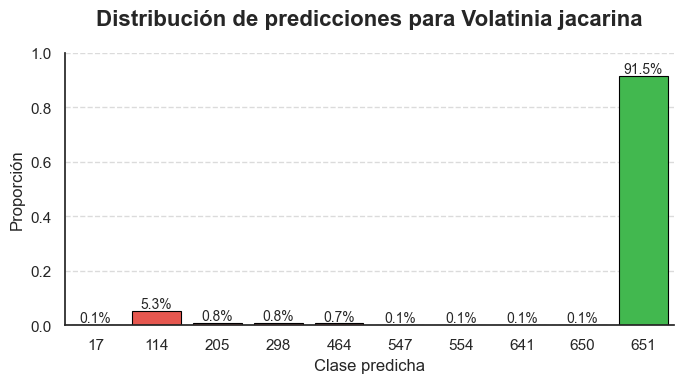

In [12]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


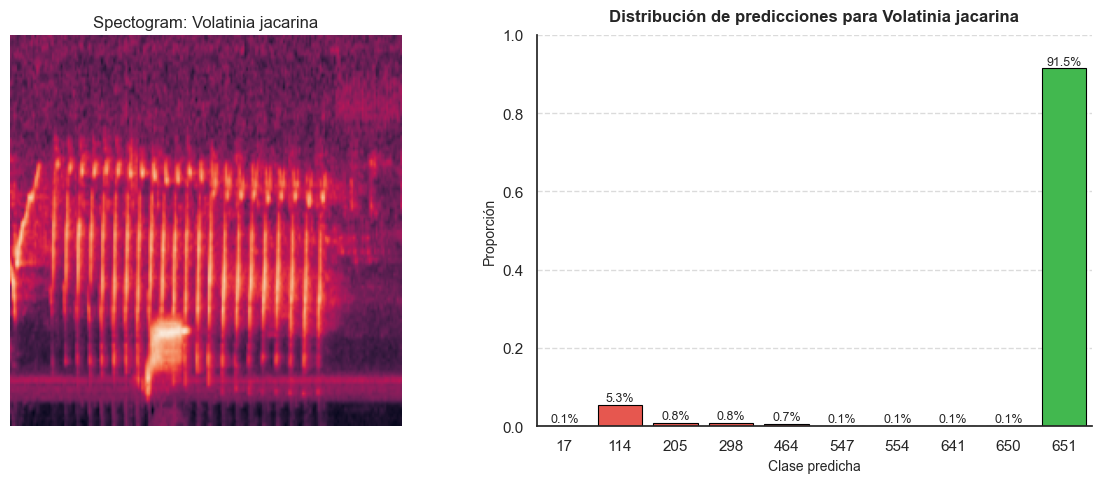

In [13]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina"
)

# **Legatus leucophaius**

In [14]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [15]:
df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-04-21 21:30:37.815645: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [12:22<00:00, 742.02s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,508,641,0.00,0,0,6.46
1,Legatus leucophaius,301,508,99,0.01,0,0,6.46
2,Legatus leucophaius,301,508,344,0.01,0,0,6.46
3,Legatus leucophaius,301,508,301,0.01,0,1,6.46
4,Legatus leucophaius,301,508,92,0.00,0,0,6.46


In [16]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [17]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,0.43
1,128,0.13
2,344,0.08
3,641,0.04
4,127,0.02
5,214,0.02
6,204,0.02
7,243,0.02
8,608,0.02
9,99,0.02


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


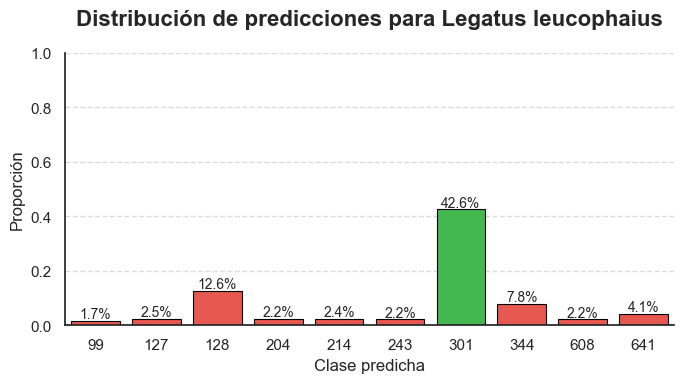

In [18]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


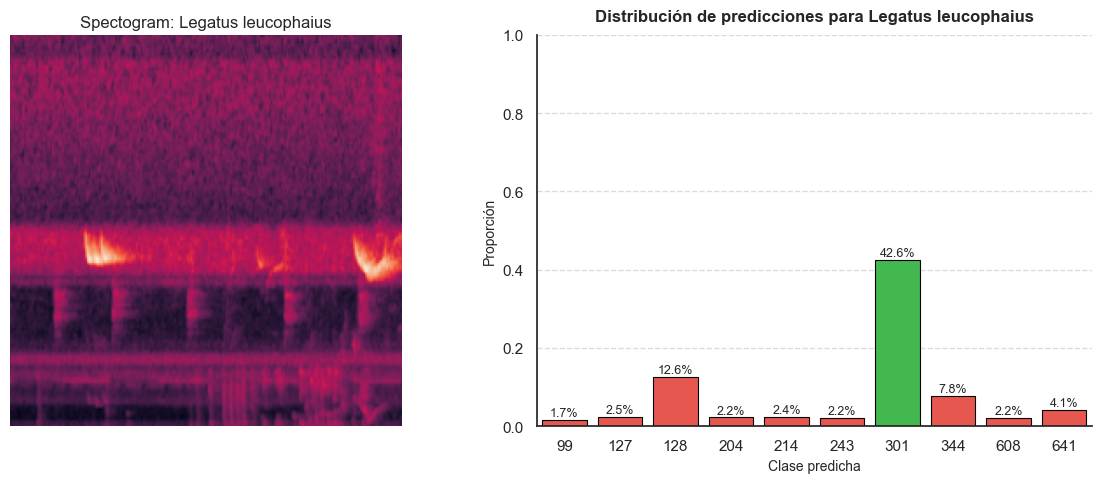

In [19]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius"
)

# **Hylophilus thoracicus**

In [20]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [21]:
df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [12:16<00:00, 736.70s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,13,274,0.01,0,1,6.46
1,Hylophilus thoracicus,274,13,274,0.01,0,1,6.46
2,Hylophilus thoracicus,274,13,452,0.01,0,0,6.46
3,Hylophilus thoracicus,274,13,161,0.00,0,0,6.46
4,Hylophilus thoracicus,274,13,301,0.00,0,0,6.46


In [22]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [23]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,0.43
1,186,0.06
2,290,0.06
3,301,0.05
4,261,0.04
5,60,0.03
6,452,0.02
7,476,0.02
8,494,0.02
9,426,0.02


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


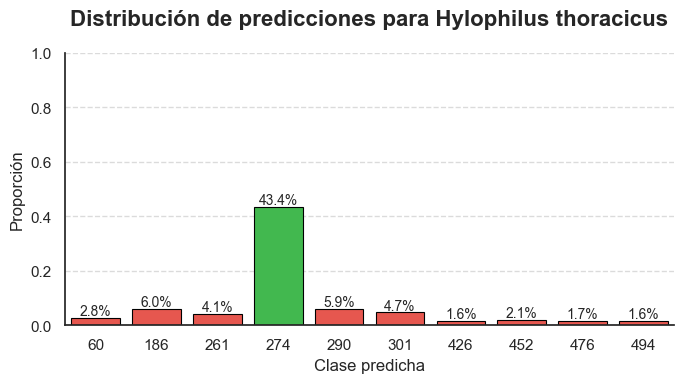

In [24]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


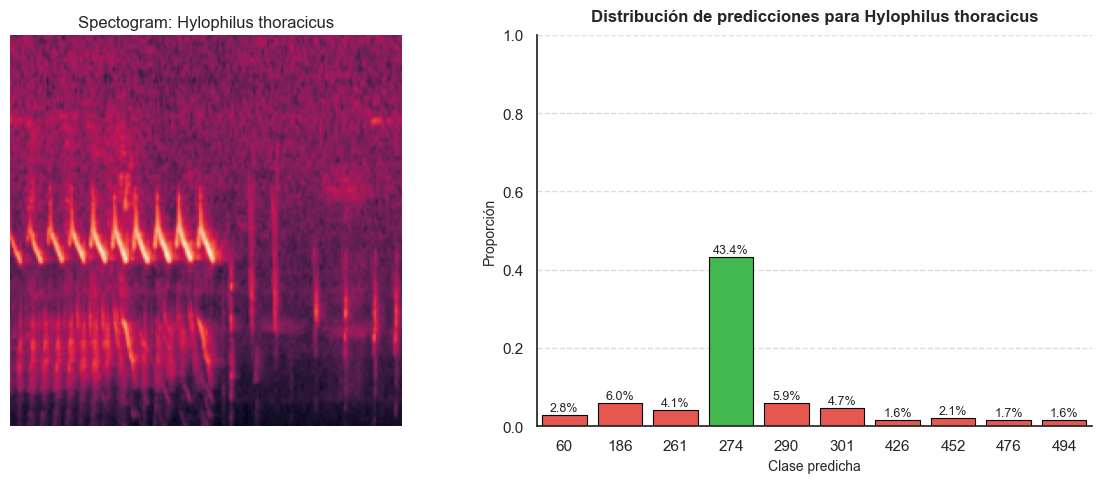

In [25]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus"
)

# **Mimus gilvus**

In [26]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [27]:
df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


2025-04-21 21:55:10.300019: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [12:12<00:00, 732.48s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,427,338,0.01,0,1,6.45
1,Mimus gilvus,338,427,544,0.01,0,0,6.45
2,Mimus gilvus,338,427,452,0.00,0,0,6.45
3,Mimus gilvus,338,427,22,0.00,0,0,6.45
4,Mimus gilvus,338,427,636,0.01,0,0,6.45


In [28]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [29]:
Mimus_gilvus

,prediccion_mc,proportion
0,636,0.14
1,495,0.09
2,338,0.08
3,494,0.07
4,640,0.07
5,544,0.06
6,621,0.06
7,316,0.04
8,666,0.04
9,65,0.03


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


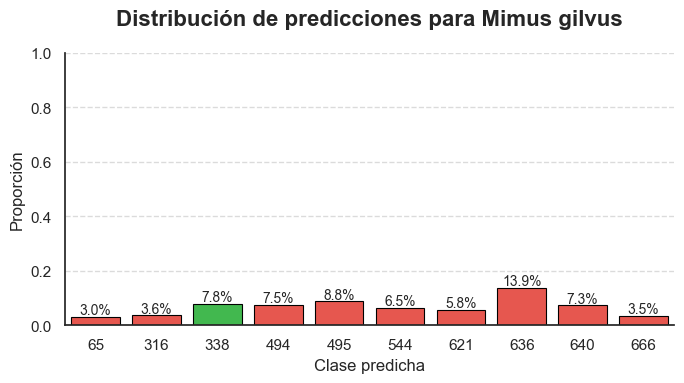

In [30]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


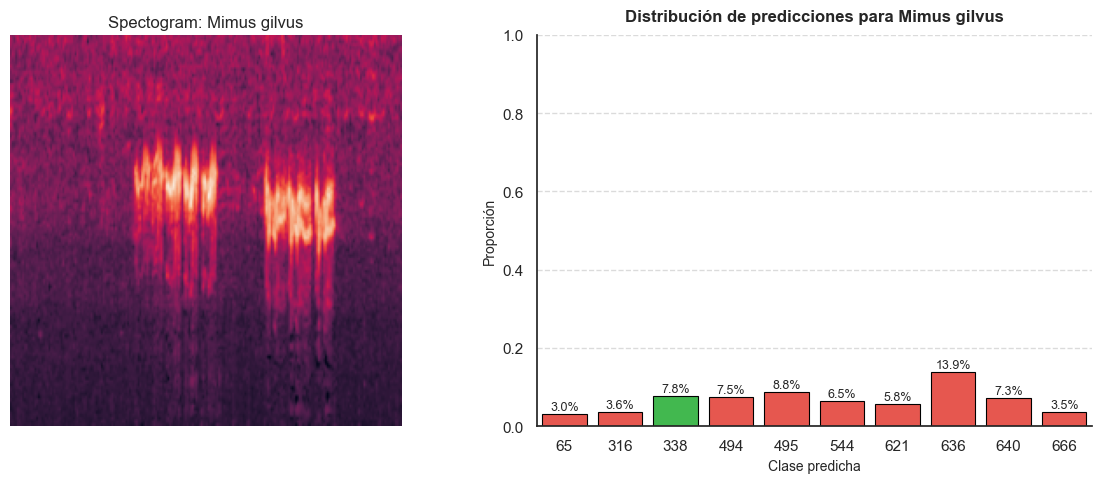

In [31]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus"
)

# **Lathrotriccus euleri**

In [32]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [33]:
df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [12:15<00:00, 735.04s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,299,300,0.00,0,1,6.46
1,Lathrotriccus euleri,300,299,112,0.01,0,0,6.46
2,Lathrotriccus euleri,300,299,297,0.01,0,0,6.46
3,Lathrotriccus euleri,300,299,300,0.01,0,1,6.46
4,Lathrotriccus euleri,300,299,662,0.01,0,0,6.46


In [34]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [35]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,0.29
1,277,0.24
2,51,0.04
3,370,0.04
4,261,0.04
5,641,0.04
6,249,0.02
7,658,0.02
8,608,0.02
9,240,0.01


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


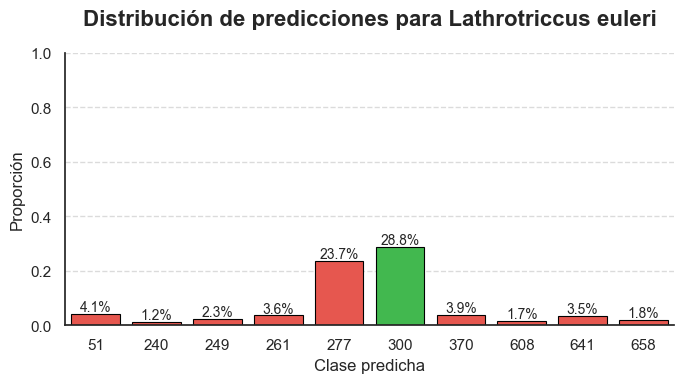

In [36]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


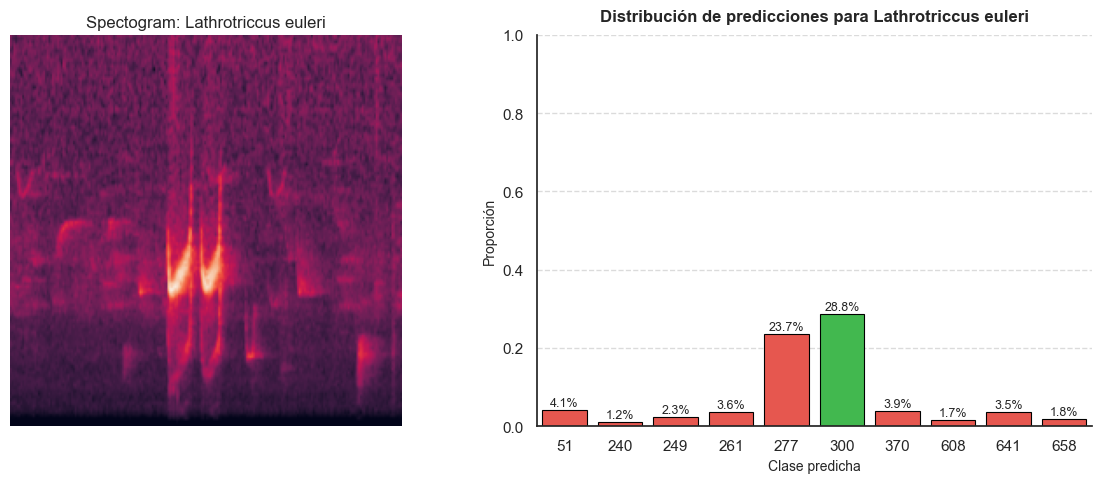

In [37]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri"
)

## **Tests**

In [38]:
sp = data[data["label"] == "Lathrotriccus euleri"]

```python
for i in range(len(sp)):
    path = sp['image_path'].iloc[i].split("/")[5]
    muestra = sp[sp['image_path'].str.contains(path)]
    df_final = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
    print(df_final)
```

In [39]:
import pandas as pd
df = pd.read_csv("src/data/incertidumbres_ResNet152V2.csv")

In [40]:
df = df.groupby('especie').agg(
    {
        'registros': 'sum',
        'true_positive': 'mean',
        'true_positivo_mc': 'mean',
        'confianza_mc': 'max',

    }
).reset_index().sample(10)

In [41]:
df.sort_values(by='true_positivo_mc', ascending=False)

,especie,registros,true_positive,true_positivo_mc,confianza_mc
608,Thraupis episcopus,75,0.36,0.21,0.01
513,Scytalopus griseicollis,50,0.72,0.14,0.01
90,Chiroxiphia lanceolata,52,0.23,0.13,0.01
499,Schiffornis turdina,75,0.72,0.13,0.01
326,Mecocerculus stictopterus,38,0.55,0.11,0.01
307,Leptopogon amaurocephalus,44,0.50,0.07,0.01
76,Celeus flavus,52,0.40,0.04,0.01
453,Premnoplex brunnescens,48,0.67,0.02,0.01
319,Loriotus luctuosus,22,0.23,0.00,0.01
461,Psarocolius viridis,51,0.35,0.00,0.01
